<a href="https://colab.research.google.com/github/Umang-Gisma/M505D/blob/main/KMeans_for_Bank_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas            as pd
import numpy             as np
import seaborn           as sns
import plotly.express    as px
import matplotlib.pyplot as plt

from imblearn.over_sampling    import SMOTE
from sklearn.preprocessing     import StandardScaler, RobustScaler, MinMaxScaler, MaxAbsScaler
from sklearn.model_selection   import train_test_split, GridSearchCV
from sklearn.linear_model      import LogisticRegression
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.tree              import DecisionTreeClassifier
from sklearn.ensemble          import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics           import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics           import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster           import KMeans
from sklearn.manifold          import TSNE


import warnings
warnings.filterwarnings("ignore")

In [5]:
APPLY_SMOTE     = False
APPLY_SCALER    = True
SHOW_CONFMATRIX = False

In [6]:
df = pd.read_csv("/content/bank_data (1).csv")
print("Shape of the dataset:", df.shape)
df.head(3)

Shape of the dataset: (10000, 13)


,id,last_name,credit_score,country,gender,age,years_customer,balance_euros,num_products,has_credit_card,is_active,salary_euros,retained
0,15634602,Hargrave,619,Switzerland,f,42,2,0.00,1,1,1,101348.88,0
1,15647311,Hill,608,Austria,f,41,1,83807.86,1,0,1,112542.58,1
2,15619304,Onio,502,Switzerland,f,42,8,159660.80,3,1,0,113931.57,0


In [7]:
df["churn"] = df["retained"].apply(lambda x: 1 if x==0 else 0)

df.drop(["id", "last_name", "retained"], axis=1, inplace=True)

df = df.join(pd.get_dummies(df['gender']))
df.drop("gender", axis=1, inplace=True)

df = df.join(pd.get_dummies(df['country']))
df.drop("country", axis=1, inplace=True)

## K-Means Clustering

In [8]:
X_unsup = df.drop("churn", axis=1).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsup)

### Elbow Method

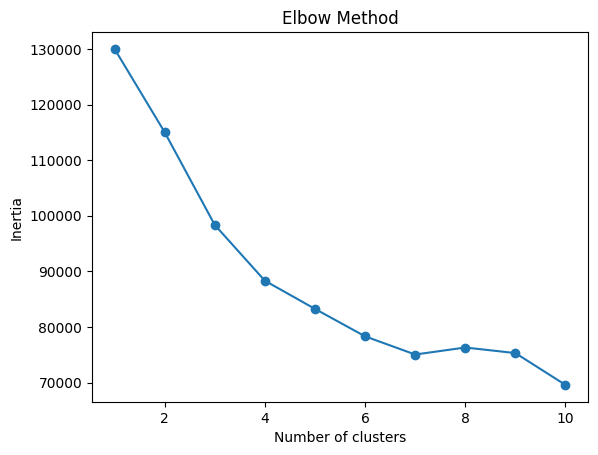

In [9]:
inertia = []

K = range(1,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### K-Meand Clustering

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["cluster"] = clusters

In [11]:
df

,credit_score,age,years_customer,balance_euros,num_products,has_credit_card,is_active,salary_euros,churn,f,m,Austria,Germany,Switzerland,cluster
0,619,42,2,0.00,1,1,1,101348.88,1,True,False,False,False,True,0
1,608,41,1,83807.86,1,0,1,112542.58,0,True,False,True,False,False,1
2,502,42,8,159660.80,3,1,0,113931.57,1,True,False,False,False,True,0
3,699,39,1,0.00,2,0,0,93826.63,0,True,False,False,False,True,0
4,850,43,2,125510.82,1,1,1,79084.10,0,True,False,True,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,True,False,False,True,2
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,True,False,False,True,2
9997,709,36,7,0.00,1,0,1,42085.58,1,True,False,False,False,True,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,False,True,False,True,False,3


In [12]:
df.groupby("cluster")["churn"].mean()

,churn
cluster,
0,0.203450
1,0.166734
2,0.127134
3,0.324432


### Apply tSNE for Visualization

In [ ]:
# t-SNE projection
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=1000
)

X_tsne = tsne.fit_transform(X_scaled)

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=clusters,
    cmap="tab10",
    alpha=0.7
)

plt.title("t-SNE Visualization of 4 Clusters")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.colorbar(label="Cluster")

plt.show()